In [249]:
import os
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Get File path and load the csv data

In [250]:
from util.data_path import soybean_price_avg as data_file

In [251]:
wide = pd.read_csv(data_file)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

### Set the training dataset and the predicted data

In [252]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [253]:
y_train = train["price"].asfreq("MS")
y_test = future["price"].asfreq("MS")

SEQ_LEN = 12
PRED_LEN = 12

### Predict the data for the next year

In [254]:
sf_data = (
    y_train.rename("y")
    .to_frame()
    .assign(ds=lambda df: df.index, unique_id="cassava")
    .reset_index(drop=True)
)

# Modified StatsForecast setup with compatible parameters
sf = StatsForecast(
    models=[
        AutoARIMA(
            season_length=12,  # Monthly data
            start_p=1,
            start_q=1,
            max_p=3,
            max_q=3,
            d=1,
            seasonal=True,
            stepwise=True,
            trace=True,  # Show model selection process
            approximation=False,
        )
    ],
    freq="MS",  # Month start
)

### Compare The Error of a predicted data and the actual data in a table format

Model information not available in this version of statsforecast


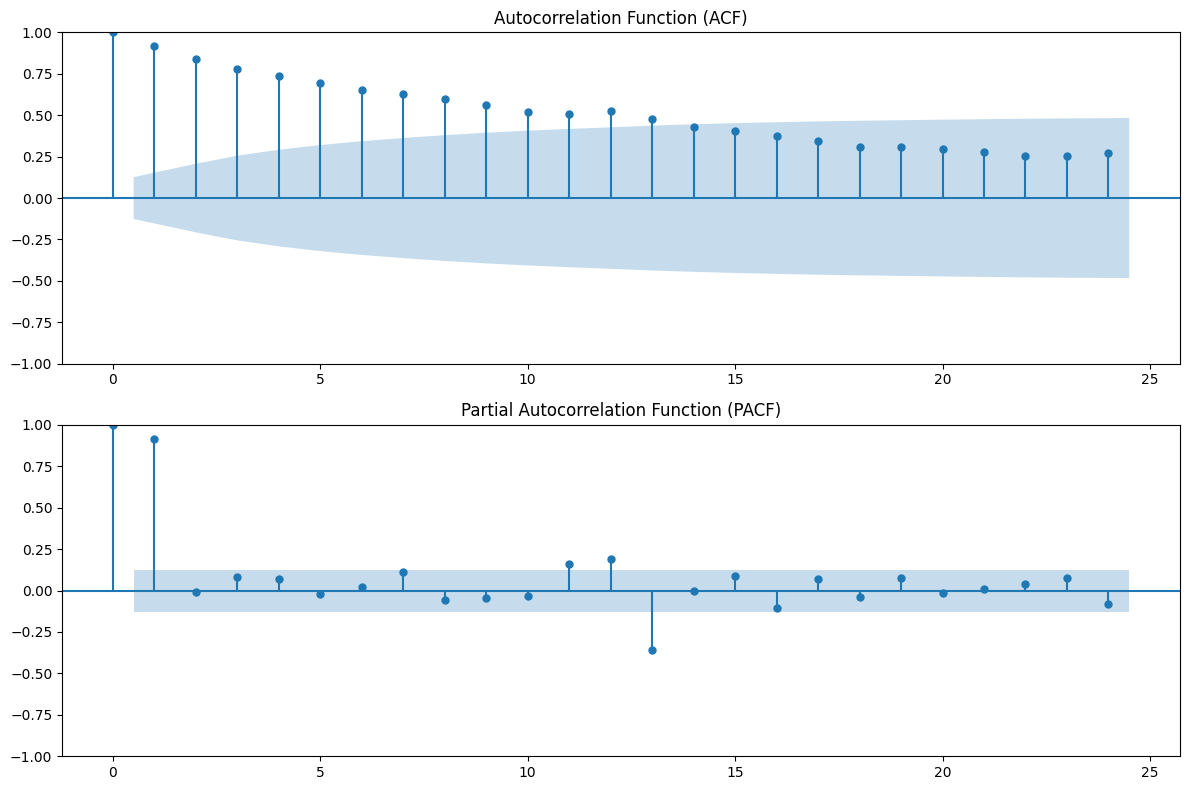

In [255]:
# Add diagnostics to check model parameters
try:
    model_info = sf.models[0].model_
    print("Selected ARIMA Model Information:")
    print(model_info)
except AttributeError:
    print("Model information not available in this version of statsforecast")

# Plot ACF and PACF to understand time series characteristics
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(y_train, lags=24, ax=ax1)
ax1.set_title("Autocorrelation Function (ACF)")
plot_pacf(y_train, lags=24, ax=ax2)
ax2.set_title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

Time Series Analysis for Model Selection:
----------------------------------------
ADF Statistic: -1.8325
p-value: 0.3645
Critical Values:
	1%: -3.4595
	5%: -2.8744
	10%: -2.5736
Series is non-stationary according to ADF test


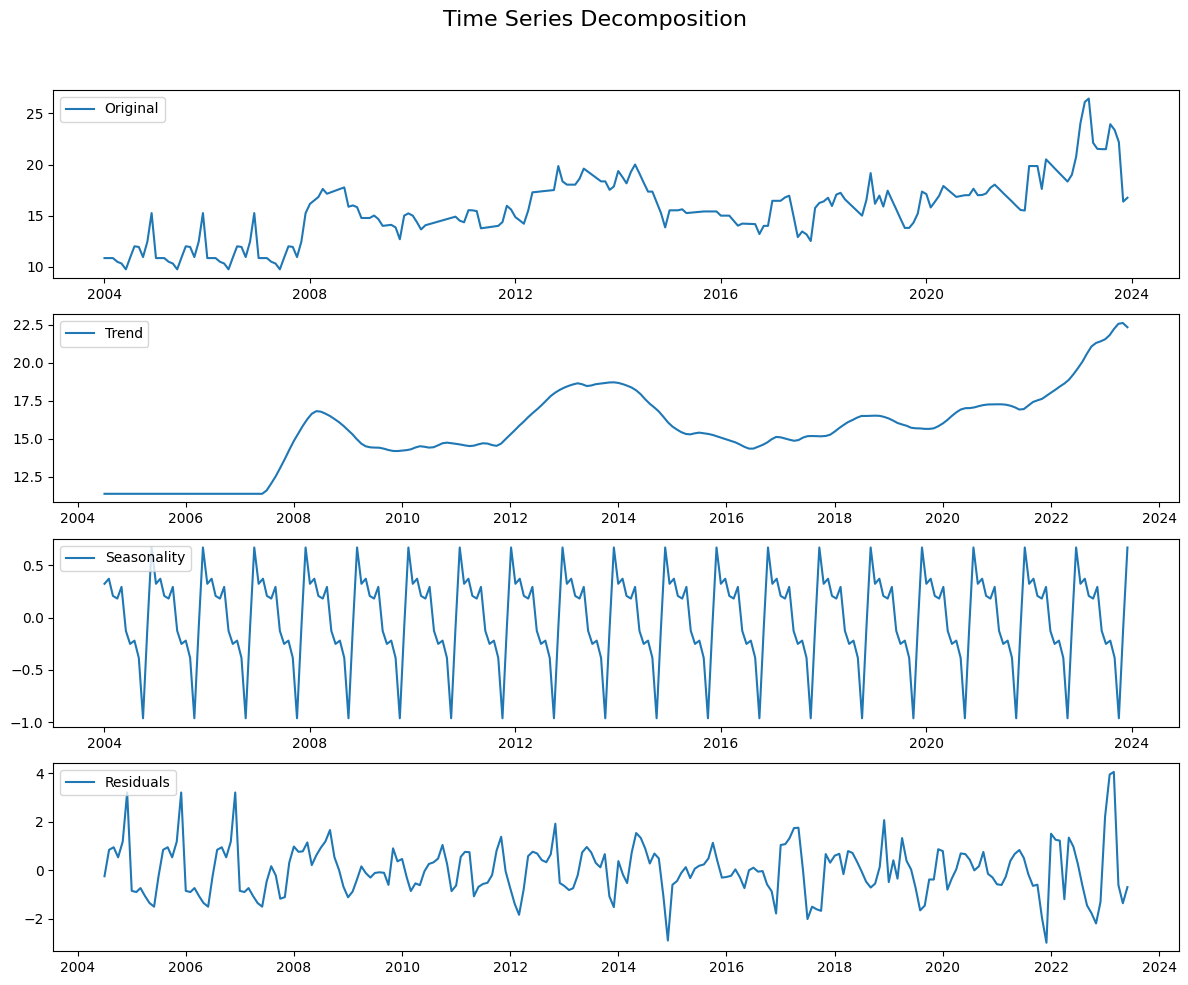


Seasonality Analysis:
Seasonal component range: -0.96 to 0.67
Seasonality strength (relative to residuals): 0.39


In [256]:
# Analyze the time series data for stationarity and seasonality
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

print("Time Series Analysis for Model Selection:")
print("-" * 40)

# 1. Check for stationarity using ADF Test
# Null hypothesis: time series is non-stationary
adf_result = adfuller(y_train.dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"\t{key}: {value:.4f}")
print(
    f"Series is {'stationary' if adf_result[1] < 0.05 else 'non-stationary'} according to ADF test"
)

# 2. Decompose the time series to see trend and seasonality
try:
    decomposition = seasonal_decompose(y_train.dropna(), model="additive", period=12)

    fig = plt.figure(figsize=(12, 10))
    fig.suptitle("Time Series Decomposition", fontsize=16)

    # Original
    ax1 = plt.subplot(411)
    ax1.plot(y_train, label="Original")
    ax1.legend(loc="upper left")

    # Trend
    ax2 = plt.subplot(412)
    ax2.plot(decomposition.trend, label="Trend")
    ax2.legend(loc="upper left")

    # Seasonality
    ax3 = plt.subplot(413)
    ax3.plot(decomposition.seasonal, label="Seasonality")
    ax3.legend(loc="upper left")

    # Residuals
    ax4 = plt.subplot(414)
    ax4.plot(decomposition.resid, label="Residuals")
    ax4.legend(loc="upper left")

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

    print("\nSeasonality Analysis:")
    print(
        f"Seasonal component range: {decomposition.seasonal.min():.2f} to {decomposition.seasonal.max():.2f}"
    )
    print(
        f"Seasonality strength (relative to residuals): {decomposition.seasonal.std() / decomposition.resid.std():.2f}"
    )

except Exception as e:
    print(f"Could not perform seasonal decomposition: {e}")

In [257]:
sf_forecasts = sf.fit_predict(df=sf_data, h=12)
arima_sf = sf_forecasts.set_index("ds")["AutoARIMA"]


error = y_test - arima_sf
abs_error = abs(error)

mae_arima = mean_absolute_error(y_test, arima_sf)
error = pd.DataFrame(
    {
        "actual": y_test,
        "arima_sf": arima_sf,
        "mae_arima": abs_error,
    }
)



ARIMA(1,1,1)(1,0,1)[12] with drift        :741.1197407242896

ARIMA(0,1,0) with drift        :772.4066182767647

ARIMA(1,1,0)(1,0,0)[12] with drift        :730.5752197068414

ARIMA(0,1,1)(0,0,1)[12] with drift        :744.1439995595753

ARIMA(0,1,0)                   :770.472530190482

ARIMA(1,1,0) with drift        :774.1339943937595

ARIMA(1,1,0)(2,0,0)[12] with drift        :732.573446638036

ARIMA(1,1,0)(1,0,1)[12] with drift        :739.0887771096662

ARIMA(1,1,0)(0,0,1)[12] with drift        :744.1436399685841

ARIMA(1,1,0)(2,0,1)[12] with drift        :749.727712305358

ARIMA(0,1,0)(1,0,0)[12] with drift        :728.3693669344375

ARIMA(0,1,0)(2,0,0)[12] with drift        :730.0869851947625

ARIMA(0,1,0)(1,0,1)[12] with drift        :736.540587370906

ARIMA(0,1,0)(0,0,1)[12] with drift        :742.0739721468622

ARIMA(0,1,0)(2,0,1)[12] with drift        :746.4133884106849

ARIMA(0,1,1)(1,0,0)[12] with drift        :730.5616295603531

ARIMA(1,1,1)(1,0,0)[12] with drift        :7

In [258]:
forecast_dir = Path("forecast_price")
forecast_dir = forecast_dir / "ARIMA"
forecast_dir.mkdir(exist_ok=True)


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"{data_file.parent.name}_forecast.txt"
filepath = forecast_dir / filename

# Save forecast data to text file
with open(filepath, "w") as f:
    f.write(
        f"ARIMA Forecast Results for {data_file.parent.name.capitalize()} Prices (2024) {timestamp}\n"
    )
    f.write("=" * 50 + "\n\n")
    f.write("Forecast Data:\n")
    f.write("-" * 20 + "\n")
    for date, price in arima_sf.items():
        f.write(f"{date.strftime('%Y-%m-%d')}: {price:.2f}\n")

    f.write("\nOverall Statistics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Arima_sf Price: {arima_sf.mean():.2f}\n")
    f.write(f"Min Arima_sf Price: {arima_sf.min():.2f}\n")
    f.write(f"Max Arima_sf Price: {arima_sf.max():.2f}\n")
    f.write(f"Standard Deviation: {arima_sf.std():.2f}\n")

print(f"Forecast prices saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Forecast prices saved to: forecast_price\ARIMA\soybean_forecast.txt
File size: 539 bytes


In [259]:
cmp = pd.concat([future["price"], arima_sf], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))

print(f"MAE ARIMA: {mae_arima:.3f}")
print(f"ARIMA Accuracy = {100 - (mae_arima / y_test.mean() * 100):.2f}%")


--- Actual vs Forecast (debug view) ---
            price  AutoARIMA
2024-01-01  19.45      18.27
2024-02-01  19.45      19.22
2024-03-01  19.45      19.37
2024-04-01  21.67      17.38
2024-05-01  19.78      17.11
2024-06-01  17.50      17.09
2024-07-01  17.38      17.09
2024-08-01  17.25      18.22
2024-09-01  17.13      17.96
2024-10-01  17.00      17.41
2024-11-01  17.00      14.74
2024-12-01  17.10      14.91
MAE ARIMA: 1.317
ARIMA Accuracy = 92.82%


### Plot The predicted data compare to an actual data

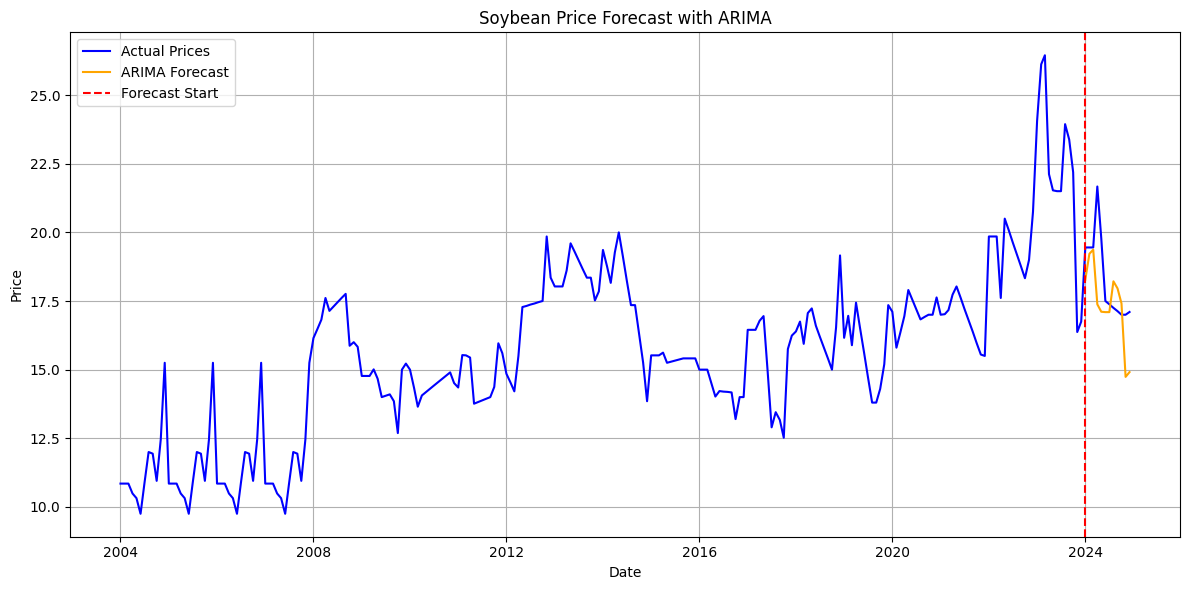

In [260]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(arima_sf.index, arima_sf, label="ARIMA Forecast", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_2567}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title(f"{data_file.parent.name.capitalize()} Price Forecast with ARIMA")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [261]:
# Try multiple ARIMA variants to compare performance
from statsforecast.models import ARIMA

# Define models with better error handling
try:
    sf_multi = StatsForecast(
        models=[
            AutoARIMA(season_length=12, approximation=False),
            # Try simpler manual ARIMA models
            ARIMA(p=1, d=1, q=0, season_length=12),  # Simple model
            ARIMA(p=1, d=1, q=1, season_length=12),  # Standard (p,d,q)=(1,1,1)
            ARIMA(p=2, d=1, q=2, season_length=12),  # More complex
        ],
        freq="MS",
    )

    # Create a new dataframe to avoid interference with existing model
    sf_data_multi = (
        y_train.rename("y")
        .to_frame()
        .assign(ds=lambda df: df.index, unique_id="cassava")
        .reset_index(drop=True)
    )

    print("Fitting multiple ARIMA models for comparison...")
    sf_multi_forecasts = sf_multi.fit_predict(df=sf_data_multi, h=12)

    # Compare results of different models
    results = {}
    plt.figure(figsize=(14, 7))
    plt.plot(long.index, long["price"], label="Actual Prices", color="blue", alpha=0.7)

    # Get all column names except 'ds' and 'unique_id'
    model_columns = [
        col for col in sf_multi_forecasts.columns if col not in ["ds", "unique_id"]
    ]

    for model_name in model_columns:
        model_forecast = sf_multi_forecasts.set_index("ds")[model_name]
        mae = mean_absolute_error(y_test, model_forecast)
        accuracy = 100 - (mae / y_test.mean() * 100)
        results[model_name] = {"MAE": mae, "Accuracy": accuracy}

        # Plot each model forecast
        plt.plot(
            model_forecast.index,
            model_forecast.values,
            label=f"{model_name} (MAE: {mae:.3f})",
            linestyle="--",
        )

    plt.axvline(
        x=pd.Timestamp(f"{gregorian_2567}-01-01"),
        color="red",
        linestyle="--",
        label="Forecast Start",
    )
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.title("Cassava Price Forecast - Multiple ARIMA Models Comparison")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print comparison results
    print("\n--- Model Comparison Results ---")
    for model, metrics in results.items():
        print(f"{model}:")
        print(f"  MAE: {metrics['MAE']:.3f}")
        print(f"  Accuracy: {metrics['Accuracy']:.2f}%")
        print("-" * 30)

    # Identify the best model based on MAE
    best_model = min(results.items(), key=lambda x: x[1]["MAE"])
    print(
        f"\nBest model: {best_model[0]} with MAE: {best_model[1]['MAE']:.3f} and Accuracy: {best_model[1]['Accuracy']:.2f}%"
    )

except Exception as e:
    print(f"Error in multi-model comparison: {e}")
    print(
        "Try running the models individually to identify which one is causing the issue."
    )

Error in multi-model comparison: ARIMA.__init__() got an unexpected keyword argument 'p'
Try running the models individually to identify which one is causing the issue.


<Figure size 1400x800 with 0 Axes>

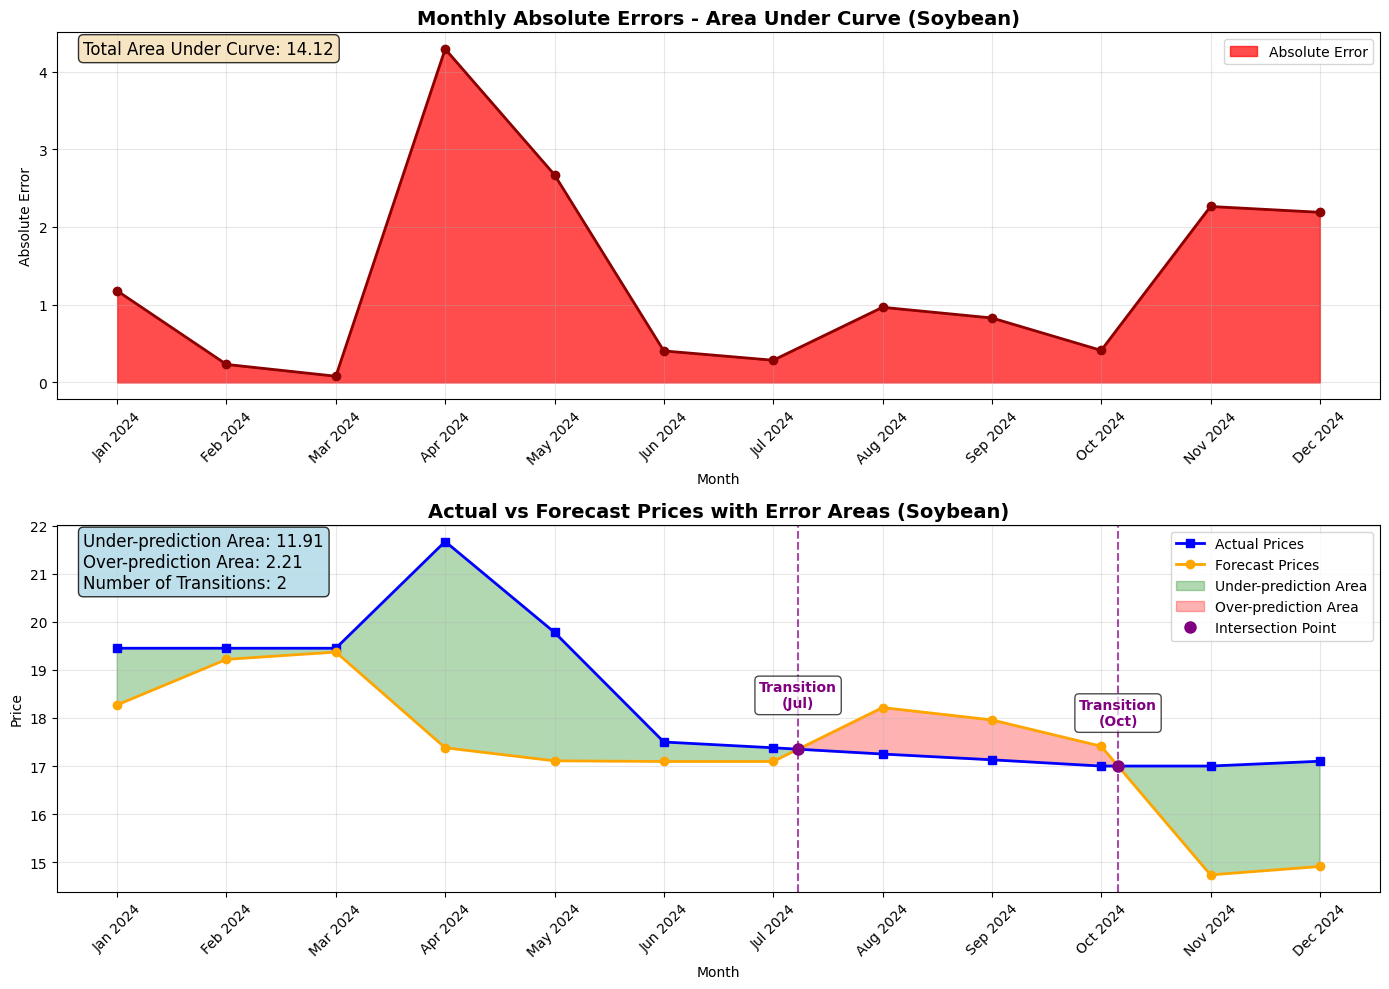

In [262]:
plt.figure(figsize=(14, 8))

# Calculate error values (in case this cell is run before the error calculation cell)
error = cmp["price"] - cmp["AutoARIMA"]
abs_error = abs(error)

# Add the error columns to the cmp DataFrame if they don't exist
if "error" not in cmp.columns:
    cmp["error"] = error
if "abs_error" not in cmp.columns:
    cmp["abs_error"] = abs_error

# Create month labels for better readability
month_labels = [date.strftime("%b %Y") for date in cmp.index]

# Create subplots for different error visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Area plot of absolute errors
ax1.fill_between(
    range(len(cmp)), cmp["abs_error"], alpha=0.7, color="red", label="Absolute Error"
)
ax1.plot(range(len(cmp)), cmp["abs_error"], color="darkred", linewidth=2, marker="o")
ax1.set_title(
    f"Monthly Absolute Errors - Area Under Curve ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Absolute Error")
ax1.set_xticks(range(len(cmp)))
ax1.set_xticklabels(month_labels, rotation=45)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add area calculation text
total_area = np.trapezoid(cmp["abs_error"])
ax1.text(
    0.02,
    0.98,
    f"Total Area Under Curve: {total_area:.2f}",
    transform=ax1.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Comparison of actual vs forecast with error areas
ax2.plot(
    range(len(cmp)),
    cmp["price"],
    label="Actual Prices",
    color="blue",
    linewidth=2,
    marker="s",
)
ax2.plot(
    range(len(cmp)),
    cmp["AutoARIMA"],
    label="Forecast Prices",
    color="orange",
    linewidth=2,
    marker="o",
)

# Find intersection points between actual and forecast
intersect_indices = []
for i in range(1, len(cmp)):
    # Check if actual and forecast cross between i-1 and i
    prev_diff = cmp["price"].iloc[i - 1] - cmp["AutoARIMA"].iloc[i - 1]
    curr_diff = cmp["price"].iloc[i] - cmp["AutoARIMA"].iloc[i]

    if (prev_diff * curr_diff <= 0) and (
        prev_diff != 0 or curr_diff != 0
    ):  # Sign change or one is zero
        # Linear interpolation to find exact intersection point
        if prev_diff == curr_diff:  # They're equal (both 0)
            t = 0  # At point i-1
        else:
            t = abs(prev_diff) / (abs(prev_diff) + abs(curr_diff))

        intersect_x = (i - 1) + t
        intersect_y = cmp["price"].iloc[i - 1] + t * (
            cmp["price"].iloc[i] - cmp["price"].iloc[i - 1]
        )

        intersect_indices.append((intersect_x, intersect_y))

# Fill areas between actual and forecast to show errors
ax2.fill_between(
    range(len(cmp)),
    cmp["price"],
    cmp["AutoARIMA"],
    where=(cmp["price"] >= cmp["AutoARIMA"]),
    color="green",
    alpha=0.3,
    label="Under-prediction Area",
    interpolate=True,
)
ax2.fill_between(
    range(len(cmp)),
    cmp["price"],
    cmp["AutoARIMA"],
    where=(cmp["price"] < cmp["AutoARIMA"]),
    color="red",
    alpha=0.3,
    label="Over-prediction Area",
    interpolate=True,
)

# Mark intersection points with vertical lines and markers
for idx, (x, y) in enumerate(intersect_indices):
    ax2.axvline(x, color="purple", linestyle="--", alpha=0.7, linewidth=1.5)
    ax2.plot(
        x,
        y,
        "o",
        color="purple",
        markersize=8,
        label="Intersection Point" if idx == 0 else "",
    )
    ax2.text(
        x,
        y * 1.05,
        f"Transition\n({month_labels[int(x)][:3]})",
        ha="center",
        color="purple",
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3"),
    )

ax2.set_title(
    f"Actual vs Forecast Prices with Error Areas ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax2.set_xlabel("Month")
ax2.set_ylabel("Price")
ax2.set_xticks(range(len(cmp)))
ax2.set_xticklabels(month_labels, rotation=45)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# Calculate and display area statistics
under_pred_area = np.trapezoid(np.maximum(cmp["price"] - cmp["AutoARIMA"], 0))
over_pred_area = np.trapezoid(np.maximum(cmp["AutoARIMA"] - cmp["price"], 0))

# Count number of transitions
num_transitions = len(intersect_indices)

# Create statistics text
stats_text = (
    f"Under-prediction Area: {under_pred_area:.2f}\n"
    f"Over-prediction Area: {over_pred_area:.2f}\n"
    f"Number of Transitions: {num_transitions}"
)

ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
)

plt.tight_layout()
plt.show()